<a href="https://colab.research.google.com/github/mAliAytekin/ai_notes/blob/main/signal_processing_gtzan_genre_collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GZTAN GENRE COLLECTION ile SİNYAL İŞLEME

## Veri Seti Hakkında Bilgi

- 10 farklı müzik türü için her türe ait 100 şarkı içerir.
- toplam veri seti her biri 30 saniye olan 1000 adet ses dosyasından oluşur.
- Müzik sınıflandırma algoritmaları için önemli bir referanstır.
- Ses dosyaları genellikle 22050 Hz mono, 16-bit formatında kaydedilmiştir.

In [ ]:
# librosa'yı kullanmak için gerek güncellemeler ve lib'ler indirilir.
!apt-get update
!apt-get install -y ffmpeg libsndfile1 gstreamer1.0-plugins-base gstreamer1.0-plugins-good gstreamer1.0-plugins-ugly gstreamer1.0-plugins-bad



Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Fetched 128 kB in 1s (97.1 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Don

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import librosa
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/My Drive/genre'
genres = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
X = []
y = []

for genre in genres:
    genre_dir = os.path.join(DATA_DIR, genre)
    for file in os.listdir(genre_dir):
        if file.endswith('.wav'):
            file_path = os.path.join(genre_dir, file)
            try:
                audio, sr = librosa.load(file_path, sr=None)
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
                mfcc_mean = np.mean(mfcc, axis=1)
                mfcc_std = np.std(mfcc, axis=1)
                zcr = librosa.feature.zero_crossing_rate(y=audio)[0]
                zcr_mean = np.mean(zcr)
                zcr_std = np.std(zcr)
                spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
                centroid_mean = np.mean(spectral_centroid)
                centroid_std = np.std(spectral_centroid)
                feat_vector = np.concatenate([mfcc_mean, mfcc_std, [zcr_mean, zcr_std, centroid_mean, centroid_std]])
                X.append(feat_vector)
                y.append(genre)
                #print(f"File Loaded: {file_path}")
            except Exception as e:
                print(f"Error loading file: {file_path} - {e}")
print(f"Finished loading files")

<ipython-input-16-4420608d9a5c>:10: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error loading file: /content/drive/My Drive/genre/jazz/jazz.00054.wav - 
Finished loading files


 ### MFCC

Ses sinyallerini temsil etmek için yaygın olarak kullanılan öznitelik kümesidir. konuşma tanımadan, müzik türü analizine kadar bir çok alanda sesin anlamlı şekilde temsil kullanımını sağlar.







1.  Framing (Çerçeveleme):
Ses sinyali kısa parçalara (ör: 20-40 ms’lik frameler) bölünür.
2.  Windowing (Pencereleme):
Her çerçeve genellikle bir pencere fonksiyonu (ör: Hamming) ile çarpılır.
3.  Fourier Transform (FFT):
Her framede frekans bileşenleri için hızlı Fourier dönüşümü alınır.
4.  Mel Filter Bank:
Frekans ekseni, insan kulağının algısına uygun olan mel skalasına dönüştürülür ve filtre bankları uygulanır.
5.  Log Enerji:
Her mel-bandı için logaritmik enerji hesaplanır.
6.  DCT (Discrete Cosine Transform):
Son olarak, bu log-enerjiler üzerinde DCT uygulanır. Böylece enerji dağlımı, düşük-mertebe katsayılara yoğunlaşır (“cepstral” dönüşüm).

İlgili kodları açıklayacak olursak:

*   `audio, sr = librosa.load(file_path, sr=None)`: `librosa` kütüphanesi kullanılarak ses dosyası yükleniyor. `librosa.load()` fonksiyonu, ses verisini (`audio`) ve örnekleme hızını (`sr`) döndürüyor. `sr=None` belirtilerek, ses dosyasının orijinal örnekleme hızı korunuyor.

*   `mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)`: Yüklenen ses verisi için MFCC (Mel-Frequency Cepstral Coefficients) özellikleri çıkarılıyor. MFCC'ler, sesin spektral özelliklerini temsil eden bir dizi katsayıdır. `n_mfcc=20` parametresi, 20 adet MFCC katsayısının çıkarılmasını sağlıyor.

*   `mfcc_mean = np.mean(mfcc, axis=1).tolist()`: Her bir MFCC katsayısının zaman içindeki ortalaması hesaplanıyor. `axis=1` parametresi, ortalamanın her bir MFCC satırı boyunca hesaplanmasını sağlıyor. Elde edilen ortalama değerler, bir Python listesine dönüştürülüyor.

In [ ]:
X = np.array(X)
le = LabelEncoder()
y = le.fit_transform(y)
y = np.array(y)


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


class AudioDataset(Dataset):
    def __init__(self, features, labels):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = AudioDataset(X_train, y_train)
test_ds = AudioDataset(X_test, y_test)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False)

## MLP ile çözümü

In [ ]:
class GenreMLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.SELU () ,
            nn.Dropout(0.1),

            nn.Linear(256, 128),
            nn.SELU () ,
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.SELU (),
            nn.Dropout(0.1),

            nn.Linear(64, out_dim)
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
genre_mlp = GenreMLP(X_train.shape[1], len(np.unique(y))).to(device)
optimizer = optim.Adam(genre_mlp.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
epoch_count=100
for epoch in range(1, epoch_count+1):
    genre_mlp.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = genre_mlp(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
genre_mlp.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)
        logits = genre_mlp(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(yb.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

genre_mlp_acc = accuracy_score(all_labels, all_preds)
genre_mlp_report =classification_report(all_labels, all_preds, target_names=le.classes_, output_dict=True)

print(f"Accuracy: {genre_mlp_acc:.2%}")
print(genre_mlp_report)

Accuracy: 55.00%
{'blues': {'precision': 0.44, 'recall': 0.55, 'f1-score': 0.4888888888888889, 'support': 20.0}, 'classical': {'precision': 0.8, 'recall': 1.0, 'f1-score': 0.8888888888888888, 'support': 20.0}, 'country': {'precision': 0.4, 'recall': 0.5, 'f1-score': 0.4444444444444444, 'support': 20.0}, 'disco': {'precision': 0.35294117647058826, 'recall': 0.6, 'f1-score': 0.4444444444444444, 'support': 20.0}, 'hiphop': {'precision': 0.6111111111111112, 'recall': 0.55, 'f1-score': 0.5789473684210527, 'support': 20.0}, 'jazz': {'precision': 0.7, 'recall': 0.7, 'f1-score': 0.7, 'support': 20.0}, 'metal': {'precision': 0.8, 'recall': 0.4, 'f1-score': 0.5333333333333333, 'support': 20.0}, 'pop': {'precision': 0.7368421052631579, 'recall': 0.7, 'f1-score': 0.717948717948718, 'support': 20.0}, 'reggae': {'precision': 0.6, 'recall': 0.3, 'f1-score': 0.4, 'support': 20.0}, 'rock': {'precision': 0.2857142857142857, 'recall': 0.2, 'f1-score': 0.23529411764705882, 'support': 20.0}, 'accuracy': 0.

## Decision Tree ile Çözümü

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred)
dt_report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

print(f"Test Accuracy: {dt_acc:.2%}")
print(dt_report)

{'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Test Accuracy: 46.50%
{'blues': {'precision': 0.47058823529411764, 'recall': 0.4, 'f1-score': 0.43243243243243246, 'support': 20.0}, 'classical': {'precision': 0.782608695652174, 'recall': 0.9, 'f1-score': 0.8372093023255814, 'support': 20.0}, 'country': {'precision': 0.24, 'recall': 0.3, 'f1-score': 0.26666666666666666, 'support': 20.0}, 'disco': {'precision': 0.2, 'recall': 0.2, 'f1-score': 0.2, 'support': 20.0}, 'hiphop': {'precision': 0.5555555555555556, 'recall': 0.5, 'f1-score': 0.5263157894736842, 'support': 20.0}, 'jazz': {'precision': 0.7222222222222222, 'recall': 0.65, 'f1-score': 0.6842105263157895, 'support': 20.0}, 'metal': {'precision': 0.5882352941176471, 'recall': 0.5, 'f1-score': 0.5405405405405406, 'support': 20.0}, 'pop': {'precision': 0.5, 'recall': 0.45, 'f1-score': 0.47368421052631576, 'support': 20.0}, 'reggae': {'precision': 0.4444444444444444, 'recal

## RandomForestClassifier ile Çözümü

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_acc =accuracy_score(y_test, y_pred)
rf_report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

print("Test Accuracy: {:.2%}".format(rf_acc))
print(rf_report)

Test Accuracy: 63.00%
{'blues': {'precision': 0.7058823529411765, 'recall': 0.6, 'f1-score': 0.6486486486486487, 'support': 20.0}, 'classical': {'precision': 0.8, 'recall': 1.0, 'f1-score': 0.8888888888888888, 'support': 20.0}, 'country': {'precision': 0.6, 'recall': 0.3, 'f1-score': 0.4, 'support': 20.0}, 'disco': {'precision': 0.5882352941176471, 'recall': 0.5, 'f1-score': 0.5405405405405406, 'support': 20.0}, 'hiphop': {'precision': 0.5652173913043478, 'recall': 0.65, 'f1-score': 0.6046511627906976, 'support': 20.0}, 'jazz': {'precision': 0.7391304347826086, 'recall': 0.85, 'f1-score': 0.7906976744186046, 'support': 20.0}, 'metal': {'precision': 0.5925925925925926, 'recall': 0.8, 'f1-score': 0.6808510638297872, 'support': 20.0}, 'pop': {'precision': 0.7058823529411765, 'recall': 0.6, 'f1-score': 0.6486486486486487, 'support': 20.0}, 'reggae': {'precision': 0.5, 'recall': 0.5, 'f1-score': 0.5, 'support': 20.0}, 'rock': {'precision': 0.47619047619047616, 'recall': 0.5, 'f1-score': 0.4

## Suppor Vector Machine ile Çözümü

In [ ]:
from sklearn.svm import SVC
svc_model = SVC(kernel="rbf", C=10, gamma='scale', random_state=42)
svc_model.fit(X_train, y_train)

y_pred = svc_model.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred)
svm_report =classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

print(f"Test Accuracy: {svm_acc:.2%}")
print(svm_report)

Test Accuracy: 38.00%
{'blues': {'precision': 0.25, 'recall': 0.3, 'f1-score': 0.2727272727272727, 'support': 20.0}, 'classical': {'precision': 0.8, 'recall': 0.8, 'f1-score': 0.8, 'support': 20.0}, 'country': {'precision': 0.125, 'recall': 0.05, 'f1-score': 0.07142857142857142, 'support': 20.0}, 'disco': {'precision': 0.25, 'recall': 0.35, 'f1-score': 0.2916666666666667, 'support': 20.0}, 'hiphop': {'precision': 0.3157894736842105, 'recall': 0.3, 'f1-score': 0.3076923076923077, 'support': 20.0}, 'jazz': {'precision': 0.47058823529411764, 'recall': 0.4, 'f1-score': 0.43243243243243246, 'support': 20.0}, 'metal': {'precision': 0.45454545454545453, 'recall': 0.75, 'f1-score': 0.5660377358490566, 'support': 20.0}, 'pop': {'precision': 0.47619047619047616, 'recall': 0.5, 'f1-score': 0.4878048780487805, 'support': 20.0}, 'reggae': {'precision': 0.16666666666666666, 'recall': 0.15, 'f1-score': 0.15789473684210525, 'support': 20.0}, 'rock': {'precision': 0.3333333333333333, 'recall': 0.2, 'f1

## Sonuçlar ve Yorum


In [ ]:
print(f"ACCURACY")

print(f"MLP Accuracy: {genre_mlp_acc:.2%}")
print(f"Decision Tree Accuracy: {dt_acc:.2%}")
print(f"Random Forest Accuracy: {rf_acc:.2%}")
print(f"SVM Accuracy: {svm_acc:.2%}")

print(f"\nCLASSFICATION_REPORT")

print("\nMLP Report:")
print(genre_mlp_report)

print("\nDecision Tree Report:")
print(dt_report)

print("\nRandom Forest Report:")
print(rf_report)

print("\nSVM Report:")
print(svm_report)

ACCURACY
MLP Accuracy: 55.00%
Decision Tree Accuracy: 48.00%
Random Forest Accuracy: 63.00%
SVM Accuracy: 38.00%

CLASSFICATION_REPORT

MLP Report:
              precision    recall  f1-score   support

       blues       0.44      0.55      0.49        20
   classical       0.80      1.00      0.89        20
     country       0.40      0.50      0.44        20
       disco       0.35      0.60      0.44        20
      hiphop       0.61      0.55      0.58        20
        jazz       0.70      0.70      0.70        20
       metal       0.80      0.40      0.53        20
         pop       0.74      0.70      0.72        20
      reggae       0.60      0.30      0.40        20
        rock       0.29      0.20      0.24        20

    accuracy                           0.55       200
   macro avg       0.57      0.55      0.54       200
weighted avg       0.57      0.55      0.54       200


Decision Tree Report:
              precision    recall  f1-score   support

       blues   

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ["MLP Report", "Decision Tree Report", "Random Forest Report", "SVM Report"]
reports = [genre_mlp_report, dt_report, rf_report, svm_report]
accuracies = [genre_mlp_acc,dt_acc,rf_acc,svm_acc]


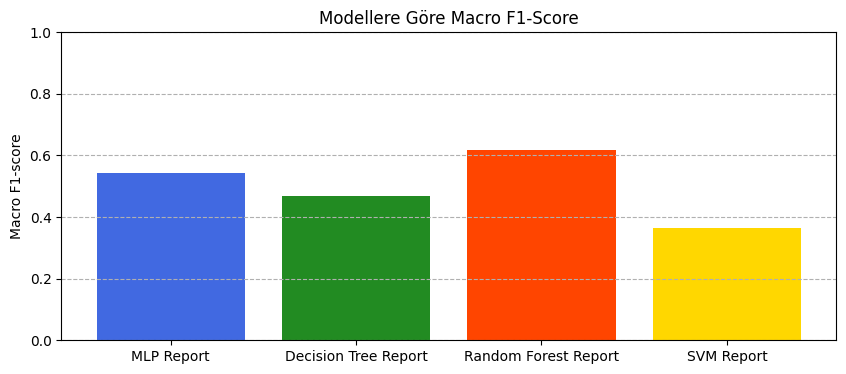

In [ ]:
macro_f1s = [r['macro avg']['f1-score'] for r in reports]

plt.figure(figsize=(10,4))
plt.bar(model_names, macro_f1s, color=['royalblue','forestgreen','orangered','gold'])
plt.title('Modellere Göre Macro F1-Score')
plt.ylabel('Macro F1-score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--')
plt.show()

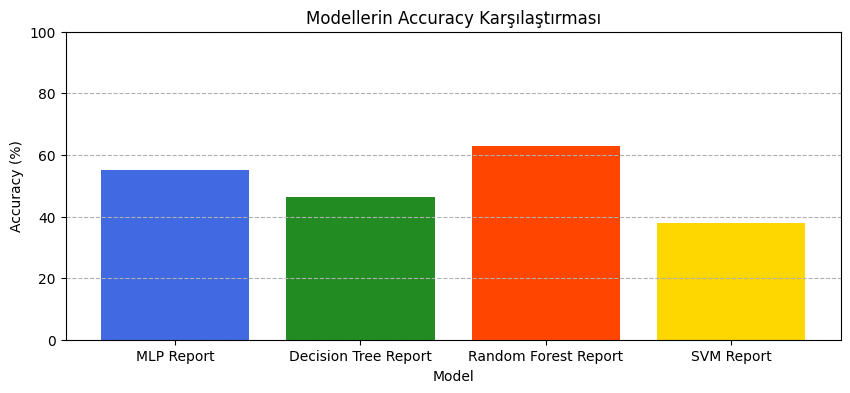

In [ ]:
plt.figure(figsize=(10,4))

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Modellerin Accuracy Karşılaştırması")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--')
plt.bar(model_names, [a*100 for a in accuracies], color=['royalblue','forestgreen','orangered','gold'])
plt.show()

## Kaynaklar

- https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
